# MNIST Handwritten Digit Classification
## End-to-End Machine Learning Pipeline

This notebook develops a complete multiclass Machine Learning pipeline for handwritten digit classification using the MNIST dataset.

The project is designed to:

- explore and understand the structure of MNIST;
- create stratified training, validation, and test subsets;
- normalize image pixels while preventing data leakage;
- train and tune three distinct Machine Learning models;
- evaluate Accuracy, weighted Precision, weighted Recall, weighted F1-score, confusion matrices, and computational cost;
- analyze common classification errors;
- investigate hidden-class and Out-of-Distribution (OOD) behavior;
- discuss model overconfidence;
- preprocess and classify handwritten digits created outside MNIST;
- generate the supporting project files required for reproducibility and GitHub documentation.

## 1. Project Overview

MNIST (Modified National Institute of Standards and Technology) is a benchmark dataset for handwritten digit recognition. Each observation represents a grayscale image of a handwritten digit from 0 to 9.

Each original image contains **28 × 28 pixels**. When flattened into a one-dimensional vector, each image contains:

\[
28 \times 28 = 784
\]

numerical features.

Three complementary classifiers are compared:

1. **K-Nearest Neighbors (KNN)** — instance-based and distance-driven learning;
2. **Random Forest** — nonlinear ensemble learning based on decision trees;
3. **Multilayer Perceptron (MLP)** — an artificial neural network that learns nonlinear relationships between pixels and classes.

Hyperparameters are selected with the validation set. The independent test set remains untouched until final model evaluation.

## 2. Objectives

The specific objectives are to:

- load and inspect MNIST;
- verify dataset dimensions, data types, classes, missing values, and pixel statistics;
- visualize one representative example from every digit class;
- analyze class balance;
- perform a stratified 70% / 10% / 20% train-validation-test split;
- normalize pixel intensities from `[0, 255]` to `[0.0, 1.0]`;
- tune at least two hyperparameters for each of three classifiers;
- compare final test performance and computational cost;
- generate a complete 10 × 10 confusion matrix for every final model;
- identify common confusion pairs and visualize representative errors;
- perform a hidden-class experiment and an OOD evaluation;
- analyze false certainty and overconfidence;
- preprocess and classify student-created handwritten images;
- automatically generate project documentation files after successful execution.

## 3. Environment Setup and Reproducibility

The project uses Python and Jupyter Notebook. Relative paths are used throughout the project so that the repository can be executed on a different computer without editing machine-specific directories.

A fixed random seed is used whenever an algorithm contains stochastic behavior. This improves reproducibility of splits and model training, although execution time can still vary between computers.

In [3]:
from pathlib import Path
from time import perf_counter
from importlib.metadata import version, PackageNotFoundError
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from PIL import Image
import cv2
import tabulate

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("default")

RANDOM_STATE = 42
IMAGE_HEIGHT = 28
IMAGE_WIDTH = 28
NUM_CLASSES = 10
PIXEL_MAX_VALUE = 255.0

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"Random state: {RANDOM_STATE}")
print(f"Image dimensions: {IMAGE_HEIGHT} x {IMAGE_WIDTH}")
print(f"Number of classes: {NUM_CLASSES}")

Random state: 42
Image dimensions: 28 x 28
Number of classes: 10


### 3.1 Project Directory Structure

The following folders separate the raw custom images, generated figures, documentation, and analysis outputs.

In [4]:
PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
CUSTOM_DIGITS_DIR = DATA_DIR / "custom_digits"

IMAGES_DIR = PROJECT_ROOT / "images"
DATASET_SAMPLES_DIR = IMAGES_DIR / "dataset_samples"
CONFUSION_MATRICES_DIR = IMAGES_DIR / "confusion_matrices"
MODEL_COMPARISON_DIR = IMAGES_DIR / "model_comparison"
OOD_ANALYSIS_DIR = IMAGES_DIR / "ood_analysis"
CUSTOM_PREDICTIONS_DIR = IMAGES_DIR / "custom_predictions"

DOCS_DIR = PROJECT_ROOT / "docs"

directories = [
    DATA_DIR,
    CUSTOM_DIGITS_DIR,
    IMAGES_DIR,
    DATASET_SAMPLES_DIR,
    CONFUSION_MATRICES_DIR,
    MODEL_COMPARISON_DIR,
    OOD_ANALYSIS_DIR,
    CUSTOM_PREDICTIONS_DIR,
    DOCS_DIR,
]

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directories created successfully.")
print(f"Project root: {PROJECT_ROOT}")

Project directories created successfully.
Project root: c:\Projects\SCTEC\mnist2


## 4. Dataset Loading

The dataset is loaded with Scikit-learn's `fetch_openml` function using the `mnist_784` representation. In this format, each 28 × 28 image is already represented as a vector containing 784 pixel-intensity features.

The target is converted to integer labels to simplify later indexing and reporting.

In [5]:
print("Loading the MNIST dataset...")

try:
    mnist = fetch_openml(
        "mnist_784",
        version=1,
        as_frame=False,
        parser="auto",
    )
except TypeError:
    # Compatibility fallback for older Scikit-learn versions.
    mnist = fetch_openml(
        "mnist_784",
        version=1,
        as_frame=False,
    )

X = mnist.data
y = mnist.target.astype(np.int64)

print("MNIST dataset loaded successfully.")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Feature data type: {X.dtype}")
print(f"Target data type: {y.dtype}")
print(f"Target classes: {np.unique(y)}")

Loading the MNIST dataset...
MNIST dataset loaded successfully.
Feature matrix shape: (70000, 784)
Target vector shape: (70000,)
Feature data type: int64
Target data type: int64
Target classes: [0 1 2 3 4 5 6 7 8 9]


## 5. Dataset Structure

Rows correspond to handwritten images and columns correspond to pixel features.

A valid MNIST representation should contain 70,000 observations, 784 features, and 10 target classes. The following checks verify the expected internal structure before modeling.

In [6]:
number_of_samples = X.shape[0]
number_of_features = X.shape[1]
expected_feature_count = IMAGE_HEIGHT * IMAGE_WIDTH

print(f"Number of samples: {number_of_samples:,}")
print(f"Number of features: {number_of_features}")
print(f"Expected flattened feature count: {expected_feature_count}")

assert number_of_features == expected_feature_count, (
    "Unexpected number of features for MNIST images."
)
assert len(np.unique(y)) == NUM_CLASSES, (
    "Unexpected number of target classes."
)

print("Dataset structure validation passed.")

Number of samples: 70,000
Number of features: 784
Expected flattened feature count: 784
Dataset structure validation passed.


## 6. Exploratory Data Analysis

The EDA verifies data integrity before training. This includes missing values, pixel range, basic pixel statistics, class counts, and class percentages.

In [7]:
has_missing_features = np.isnan(X).any()
has_missing_targets = pd.isna(y).any()

pixel_statistics_df = pd.DataFrame(
    {
        "Statistic": ["Minimum", "Maximum", "Mean", "Standard Deviation"],
        "Pixel Value": [
            float(np.min(X)),
            float(np.max(X)),
            float(np.mean(X)),
            float(np.std(X)),
        ],
    }
)

print(f"Missing values in features: {has_missing_features}")
print(f"Missing values in targets: {has_missing_targets}")
display(pixel_statistics_df)

Missing values in features: False
Missing values in targets: False


,Statistic,Pixel Value
0,Minimum,0.000000
1,Maximum,255.000000
2,Mean,33.385965
3,Standard Deviation,78.654374


### 6.1 Class Distribution

For each class, the absolute sample count and its percentage of the full dataset are calculated. A reasonably balanced class distribution is desirable because no digit should dominate the learning objective merely because it appears far more frequently than the others.

,digit,sample_count,percentage
0,0,6903,9.861429
1,1,7877,11.252857
2,2,6990,9.985714
3,3,7141,10.201429
4,4,6824,9.748571
5,5,6313,9.018571
6,6,6876,9.822857
7,7,7293,10.418571
8,8,6825,9.750000
9,9,6958,9.940000


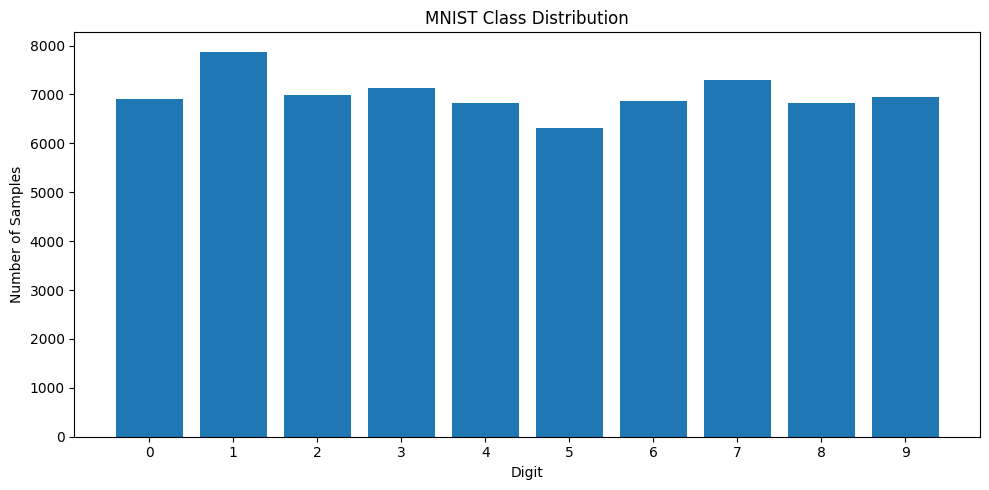

Largest-to-smallest class size ratio: 1.248


In [8]:
digits, class_counts = np.unique(y, return_counts=True)

class_distribution_df = pd.DataFrame(
    {
        "digit": digits,
        "sample_count": class_counts,
        "percentage": class_counts / len(y) * 100,
    }
)

display(class_distribution_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(class_distribution_df["digit"], class_distribution_df["sample_count"])
ax.set_title("MNIST Class Distribution")
ax.set_xlabel("Digit")
ax.set_ylabel("Number of Samples")
ax.set_xticks(range(NUM_CLASSES))
plt.tight_layout()

class_distribution_path = DATASET_SAMPLES_DIR / "class_distribution.png"
fig.savefig(class_distribution_path, dpi=150, bbox_inches="tight")
plt.show()

class_balance_ratio = (
    class_distribution_df["sample_count"].max()
    / class_distribution_df["sample_count"].min()
)
print(f"Largest-to-smallest class size ratio: {class_balance_ratio:.3f}")

In [9]:
balance_interpretation = f"""
### Class Balance Interpretation

The largest-to-smallest class size ratio is **{class_balance_ratio:.3f}**.

A ratio close to 1 indicates that the classes have similar sample sizes. MNIST is therefore sufficiently balanced for a direct multiclass comparison, although small differences in class support remain. Weighted metrics will later account for these support differences when Precision, Recall, and F1-score are summarized across classes.
"""
display(Markdown(balance_interpretation))


### Class Balance Interpretation

The largest-to-smallest class size ratio is **1.248**.

A ratio close to 1 indicates that the classes have similar sample sizes. MNIST is therefore sufficiently balanced for a direct multiclass comparison, although small differences in class support remain. Weighted metrics will later account for these support differences when Precision, Recall, and F1-score are summarized across classes.


## 7. Visualization of MNIST Digits

The following 2 × 5 grid displays one example from each class. The one-dimensional 784-feature vector is reshaped back into a 28 × 28 matrix only for visualization.

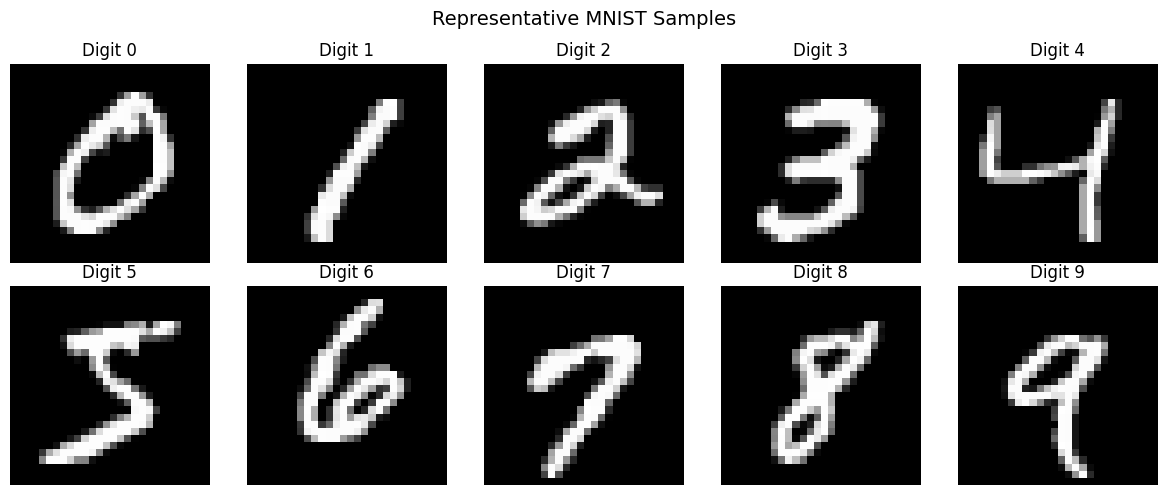

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for digit, ax in zip(range(NUM_CLASSES), axes.ravel()):
    sample_index = np.where(y == digit)[0][0]
    image = X[sample_index].reshape(IMAGE_HEIGHT, IMAGE_WIDTH)

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Digit {digit}")
    ax.axis("off")

fig.suptitle("Representative MNIST Samples", fontsize=14)
plt.tight_layout()

sample_grid_path = DATASET_SAMPLES_DIR / "representative_mnist_digits.png"
fig.savefig(sample_grid_path, dpi=150, bbox_inches="tight")
plt.show()

### 7.1 Understanding Pixel Intensities and the 784-Dimensional Feature Space

A grayscale pixel is represented numerically. In the original MNIST representation, the expected intensity range is from 0 to 255.

- values close to 0 represent the background;
- larger values represent stronger foreground strokes;
- each 28 × 28 image contains 784 ordered pixel values.

The two-dimensional image:

\[
28 \times 28
\]

is flattened into the feature vector:

\[
x = [x_1, x_2, \ldots, x_{784}]
\]

so that conventional Machine Learning algorithms can receive the dataset as a matrix whose rows are samples and whose columns are numerical features.